In [4]:
import zipfile
import os

# 파일 경로 설정
zip_file_path = r'../wafer_anal_prj/LSWMD.pkl.zip'
extract_dir = r'../wafer_anal_prj/extracted_files'  # 압축을 풀 위치 설정

# zip 파일 압축 풀기
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"파일이 {extract_dir}에 압축 풀렸습니다.")


파일이 ../wafer_anal_prj/extracted_files에 압축 풀렸습니다.


In [5]:
import os
import pickle

import sys
import pandas as pd
sys.modules['pandas.indexes'] = pd.core.indexes

# 실제 디렉토리 경로 설정
extract_dir = '../wafer_anal_prj/extracted_files'  # 실제 경로로 변경

# pkl 파일 경로 설정
pkl_file_path = os.path.join(extract_dir, 'LSWMD.pkl')

# 파일 경로 확인
if not os.path.exists(pkl_file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {pkl_file_path}")

# pkl 파일 로드
with open(pkl_file_path, 'rb') as file:
    data = pickle.load(file, encoding="latin1")  # encoding을 latin1로 변경

print("데이터가 성공적으로 로드되었습니다.")
print(data.head())  # 데이터의 처음 몇 줄 확인

데이터가 성공적으로 로드되었습니다.
                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  


In [6]:
import os
import pickle
import numpy as np
import pandas as pd

# pkl 파일 경로 설정
extract_dir = 'D:/wafer_anal_prj/extracted_files'  # 실제 경로로 변경
pkl_file_path = os.path.join(extract_dir, 'LSWMD.pkl')

# 파일 경로 확인
if not os.path.exists(pkl_file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {pkl_file_path}")

# pkl 파일 로드
with open(pkl_file_path, 'rb') as file:
    data = pickle.load(file, encoding="latin1")  # encoding을 latin1로 변경

# 데이터가 DataFrame인지 확인
if isinstance(data, pd.DataFrame):
    df_withpattern = data
else:
    # 데이터가 dict 또는 list 형태라면 DataFrame으로 변환
    df_withpattern = pd.DataFrame(data)

# 데이터 구조 확인
print(df_withpattern.info())
print(df_withpattern.head())

# 결측값 처리
df_withpattern.dropna(subset=['waferMap', 'failureType'], inplace=True)

# failureType 인코딩
labels2 = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

def encode_failure_type(x):
    if x and x[0][0] in labels2:
        return labels2.index(x[0][0])
    else:
        return -1  # labels2에 없는 값은 -1로 처리

df_withpattern['failureType_encoded'] = df_withpattern['failureType'].apply(encode_failure_type)

# waferMap 정규화
df_withpattern['waferMap_normalized'] = df_withpattern['waferMap'].apply(lambda x: np.array(x) / 255.0)

# 필요 없는 열 제거
df_withpattern.drop(columns=['failureType'], inplace=True)

# 전처리된 데이터 저장
df_withpattern.to_pickle('../wafer_anal_prj/processed_df_withpattern.pkl')
print("전처리된 데이터가 저장되었습니다.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB
None
                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLa

C:\Users\oi3oi\AppData\Local\Temp\ipykernel_6688\4024089238.py:36: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if x and x[0][0] in labels2:


전처리된 데이터가 저장되었습니다.


In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 전처리된 데이터 로드
processed_data_path = '../wafer_anal_prj/processed_df_withpattern.pkl'
df_withpattern = pd.read_pickle(processed_data_path)

# 데이터 분할 비율 설정
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# 데이터 셔플링 및 분할
train_data, temp_data = train_test_split(df_withpattern, test_size=(1 - train_ratio), random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=(test_ratio / (test_ratio + val_ratio)), random_state=42)

# 분할된 데이터 크기 확인
print(f"Training data: {len(train_data)} rows")
print(f"Validation data: {len(val_data)} rows")
print(f"Test data: {len(test_data)} rows")

# 분할된 데이터 저장
train_data.to_pickle('../wafer_anal_prj/train_data.pkl')
val_data.to_pickle('../wafer_anal_prj/val_data.pkl')
test_data.to_pickle('../wafer_anal_prj/test_data.pkl')

print("Training, validation, and test data가 저장되었습니다.")

Training data: 568019 rows
Validation data: 121719 rows
Test data: 121719 rows
Training, validation, and test data가 저장되었습니다.


In [8]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
# 분류된 데이터 로드
train_data = pd.read_pickle('../wafer_anal_prj/train_data.pkl')
val_data = pd.read_pickle('../wafer_anal_prj/val_data.pkl')
test_data = pd.read_pickle('../wafer_anal_prj/test_data.pkl')

# 데이터 확인
print(f"Training data shape: {train_data.shape}")
print(f"Validation data shape: {val_data.shape}")
print(f"Test data shape: {test_data.shape}")

Training data shape: (568019, 7)
Validation data shape: (121719, 7)
Test data shape: (121719, 7)


In [10]:
from scipy.ndimage import zoom
import numpy as np

def resize_array(arr, target_shape):
    arr = np.array(arr)
    zoom_factors = (target_shape / arr.shape[0], target_shape / arr.shape[1])
    return zoom(arr, zoom_factors, order=1)  # bilinear

target_shape = 64  # 또는 64 등 더 작은 값으로 조정

train_data['waferMap_normalized'] = train_data['waferMap_normalized'].apply(lambda x: resize_array(x, target_shape))
val_data['waferMap_normalized'] = val_data['waferMap_normalized'].apply(lambda x: resize_array(x, target_shape))
test_data['waferMap_normalized'] = test_data['waferMap_normalized'].apply(lambda x: resize_array(x, target_shape))

X_train = np.stack(train_data['waferMap_normalized'].values).astype(np.float32)
y_train = train_data['failureType_encoded']

X_val = np.stack(val_data['waferMap_normalized'].values).astype(np.float32)
y_val = val_data['failureType_encoded']

X_test = np.stack(test_data['waferMap_normalized'].values).astype(np.float32)
y_test = test_data['failureType_encoded']

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (568019, 64, 64), y_train shape: (568019,)
X_val shape: (121719, 64, 64), y_val shape: (121719,)
X_test shape: (121719, 64, 64), y_test shape: (121719,)


In [11]:
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

# -1(분류 불가) 데이터 제거
train_data = train_data[train_data['failureType_encoded'] != -1]
val_data = val_data[val_data['failureType_encoded'] != -1]
test_data = test_data[test_data['failureType_encoded'] != -1]

# 리사이즈 적용
from scipy.ndimage import zoom
def resize_array(arr, target_shape):
    arr = np.array(arr)
    zoom_factors = (target_shape / arr.shape[0], target_shape / arr.shape[1])
    return zoom(arr, zoom_factors, order=1)

target_shape = 64
train_data['waferMap_normalized'] = train_data['waferMap_normalized'].apply(lambda x: resize_array(x, target_shape))
val_data['waferMap_normalized'] = val_data['waferMap_normalized'].apply(lambda x: resize_array(x, target_shape))
test_data['waferMap_normalized'] = test_data['waferMap_normalized'].apply(lambda x: resize_array(x, target_shape))

# X, y 생성
X_train = np.stack(train_data['waferMap_normalized'].values).astype(np.float32)
y_train = train_data['failureType_encoded']
X_val = np.stack(val_data['waferMap_normalized'].values).astype(np.float32)
y_val = val_data['failureType_encoded']
X_test = np.stack(test_data['waferMap_normalized'].values).astype(np.float32)
y_test = test_data['failureType_encoded']

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 랜덤시드 40으로 설정
np.random.seed(40)

# 2D 이미지를 1D 벡터로 변환 (랜덤포레스트는 1D 입력 필요)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 모델 학습
clf = RandomForestClassifier(n_estimators=100, random_state=40)
clf.fit(X_train_flat, y_train)

# 검증 데이터 평가
y_val_pred = clf.predict(X_val_flat)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

# 테스트 데이터 평가
y_test_pred = clf.predict(X_test_flat)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

Validation Accuracy: 0.8557540725170782
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       647
           1       0.94      0.62      0.75        79
           2       0.71      0.92      0.80       784
           3       0.99      0.97      0.98      1447
           4       0.67      0.63      0.65       537
           5       0.87      0.76      0.81       123
           6       0.85      0.13      0.23       166
           7       1.00      0.70      0.82        23

    accuracy                           0.86      3806
   macro avg       0.87      0.71      0.75      3806
weighted avg       0.86      0.86      0.84      3806

Test Accuracy: 0.8689600840336135
Test Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       685
           1       0.90      0.63      0.74       101
           2       0.73      0.95      0.82       

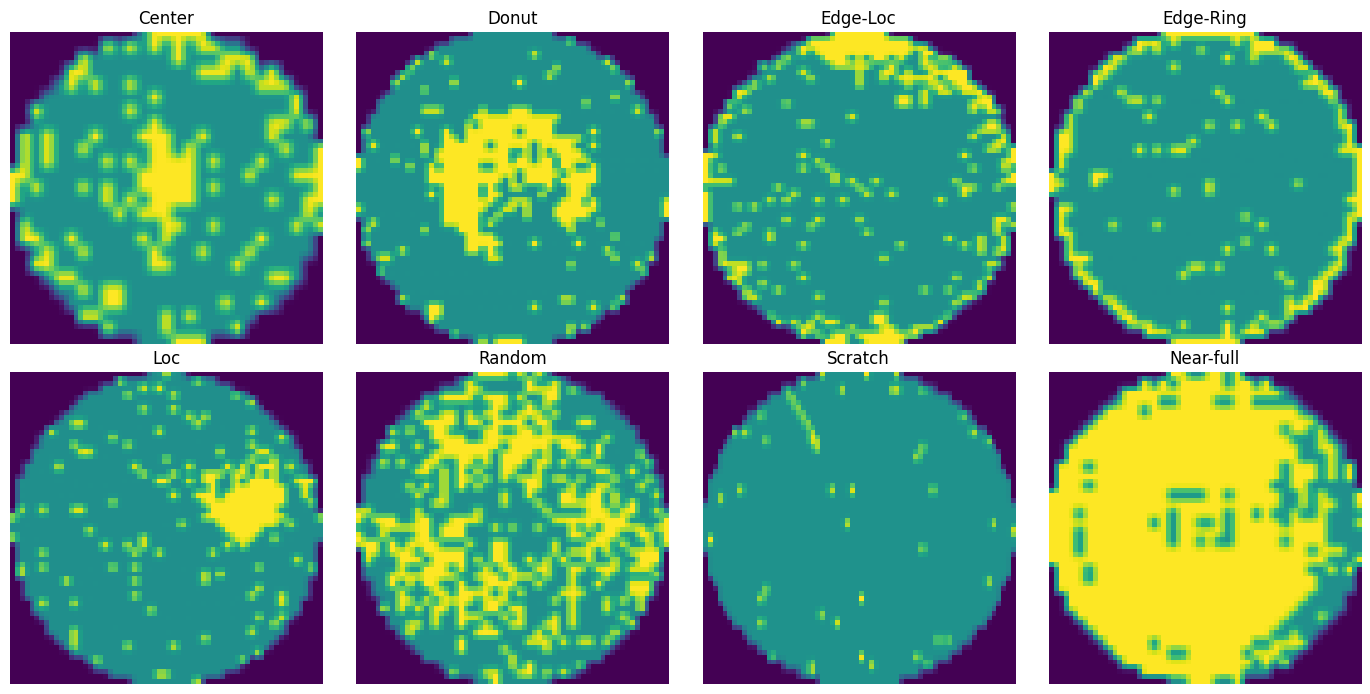

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

def pad_to_square(arr, pad_value=0):
    arr = np.array(arr)
    h, w = arr.shape
    size = max(h, w)
    pad_h = (size - h) // 2
    pad_w = (size - w) // 2
    arr_padded = np.pad(arr, ((pad_h, size - h - pad_h), (pad_w, size - w - pad_w)),
                        mode='constant', constant_values=pad_value)
    return arr_padded

def resize_array(arr, target_shape):
    arr = np.array(arr)
    # 최근접 이웃, anti_aliasing 끄기
    return resize(arr, (target_shape, target_shape), order=0, preserve_range=True, anti_aliasing=False)

def preprocess_wafer(arr, target_shape=64):
    arr = pad_to_square(arr)
    return resize_array(arr, target_shape)

# 적용
target_shape = 64  # 원하는 크기
train_data['waferMap_normalized'] = train_data['waferMap_normalized'].apply(lambda x: preprocess_wafer(x, target_shape))

# 시각화
labels2 = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
num_images = 8
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, label in enumerate(labels2):
    # 해당 label의 첫 번째 샘플 찾기
    idx = train_data[train_data['failureType_encoded'] == i].index[0]
    img = train_data.loc[idx, 'waferMap_normalized']
    ax = axes[i // 4, i % 4]
    ax.imshow(img, cmap='viridis')  # 예시와 비슷한 컬러맵
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()